# DSM Assignment 1
Please pay attention to the following instructions:
1. Please follow carefully the steps outlined in the assignment. If you cannot solve an exercise and this hinders continuing with subsequent exercises, try to find a way to work around it and give a clear explanation for the solution you have chosen.
2. Submit your work in the form of a Jupyter notebook via Canvas, before the deadline. Your notebook should not give errors when executed with `Run All`.

- 15468666 Jasmine Yang

## Part 0: importing the relevant libraries

**Exercise 1:** import all the libraries you are using in this notebook.

In [1]:
import math
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from scipy.stats import norm
from statsmodels.nonparametric.kernel_regression import KernelReg
from sklearn.pipeline import make_pipeline

## Part 1: wrangling and analyzing Twitter sentiment data
This part of the assignment is about wrangling and analyzing Twitter sentiment data for six airline companies:

|**Name Airline**|**@username**|
|:-------|:-------------|
|American Airlines       |@AmericanAir           |
|JetBlue Airways        |@JetBlue              |
|Southwest Airlines       |@SouthwestAir           |
|United Airlines        |@united              |
|US Airways        |@USAirways              |
|Virgin America       |@VirginAmerica             |

The dataset `DSM_assignment1_twitter_data.csv` consists of more than 14.000 tweets sent on 9 consecutive days in February 2015, all addressing one (or more) of the aforementioned airlines via the @username syntax. The text of the tweets can be found in the `text` column of the dataset. Another relevant column is called `tweet_created`, giving the time and day at which the tweet was sent.

Furthermore, a machine learning algorithm has analyzed the content of the tweets and categorized the sentiment as positive, neutral or negative. This data can be found in `DSM_assignment1_sentiment_data.csv`. The sentiment can be found in the `airline_sentiment` column. The machine learning algorithm also estimates the probability that it identified the correct sentiment, which is given in the `airline_sentiment:confidence` column.

The column `_unit_id` can be found in both datasets and can be used as a key to match the tweets with the sentiment data.

(Note: US Airways was integrated into American Airlines in October 2015. Since our dataset is from February 2015, we will consider them as separate airlines.)

**Exercise 2:** import the datasets `DSM_assignment1_twitter_data.csv` and `DSM_assignment1_sentiment_data.csv` and turn them into two DataFrames, called respectively `df_twitter` and `df_sentiment`.

In [2]:
df_twitter = pd.read_csv('data/DSM_assignment1_twitter_data.csv')
df_sentiment = pd.read_csv('data/DSM_assignment1_sentiment_data.csv')

**Exercise 3:** during the creation of both datasets some lines/rows were duplicated. Remove the duplicates from both DataFrames.

In [3]:
df_twitter.drop_duplicates(inplace=True)
df_sentiment.drop_duplicates(inplace=True)

**Exercise 4:** the machine learning algorithm is not always able to extract a sentiment from the tweet. This is reflected in a missing `airline_sentiment` value in `df_sentiment`. Remove the lines with a missing airline sentiment from the DataFrame and call the new DataFrame `df_sentiment_notnull`. Report the number of discarded lines by printing it.

In [4]:
df_sentiment_notnull = df_sentiment[df_sentiment['airline_sentiment'].isnull() == False]
discardedline_count = df_sentiment.shape[0] - df_sentiment_notnull.shape[0]

print("The number of discarded lines:", discardedline_count)

The number of discarded lines: 36


**Exercise 5:** use the column `_unit_id` to merge the DataFrames `df_twitter` and `df_sentiment_notnull`. Call the resulting DataFrame `df`. Make sure that `df` contains only the entries that have both Twitter and sentiment data.

Report the total number of tweets in the merged dataset, as well as the number of removed tweets from the Twitter dataset and the number of removed tweets from the sentiment dataset.

In [16]:
df = pd.merge(df_twitter, df_sentiment_notnull, on = '_unit_id')

total_num_of_tweets = df.shape[0]

sentiment_remove = df_sentiment_notnull.shape[0] - df.shape[0]
twitter_remove = df_twitter.shape[0] - df.shape[0]


print("Total number of tweets in the merged dataset:", total_num_of_tweets)
print("Number of removed tweets from the Twitter dataset:", twitter_remove)
print("Number of removed tweets from the sentiment dataset:", sentiment_remove)

Total number of tweets in the merged dataset: 14484
Number of removed tweets from the Twitter dataset: 46
Number of removed tweets from the sentiment dataset: 109


**Exercise 6:** crucially, what is still missing in the data is a column with the airline company that is being addressed in the tweet. This is done using Twitter's @username syntax, which is called a *mention*. For example, if the text of a tweet contains the (sub)string `@AmericanAir`, we may assume the tweet is addressed to American Airlines. We have to extract this information from the text of the tweet. This can be done using regular expressions and the `re` package of Python, for instance (see [this](https://regexone.com) website for basic instructions). However, we have to be careful, as some tweets contain multiple mentions.

Use the cell below to execute the following:
* create a new column called `mentions` in the `df`. The values of this column must be **lists** containing **all** the @username occurences (string type) in the text of a tweet. You can use regular expressions for extracting the @username occurences.
* print the total number of mentions you have extracted from all tweets together, as well as the average number of mentions per tweet. Furthermore, draw a random sample of 15 entries of the `mentions` column and print the sample (as a Series).

You are strongly encouraged to use the GitHub Copilot for this exercise (see also the next exercise).

In [ ]:
df['mentions'] = df['text'].apply(lambda x: re.findall(r'@\w+', x))

total_mentions = df['mentions'].apply(len).sum()
average_mentions = total_mentions / total_num_of_tweets

#Draw a random sample of 15 entries
sample_mentions = df['mentions'].sample(15, random_state=42)

#----------------------------------------------
print(f"Total number of mentions: {total_mentions}")
print(f"Average number of mentions per tweet: {average_mentions}")
print("\nRandom sample of 15 mentions lists:")
print(sample_mentions)

Total number of mentions: 16336
Average number of mentions per tweet: 1.127865230599282

Random sample of 15 mentions lists:
14442                     [@SouthwestAir]
9285                      [@SouthwestAir]
2366                         [@USAirways]
3325                         [@USAirways]
169                      [@VirginAmerica]
2034        [@SouthwestAir, @BWI_Airport]
5257                            [@united]
1944     [@SouthwestAir, @Imaginedragons]
4436                           [@JetBlue]
8823                         [@USAirways]
8348                            [@united]
6013                         [@USAirways]
5762                           [@JetBlue]
5787                         [@USAirways]
3855                      [@SouthwestAir]
Name: mentions, dtype: object


**Exercise 7:** write a GitHub Copilot prompt that solves the previous exercise.

Report the prompt in this markdown cell here: 

### GitHub Copilot Prompt:
DataFrame `df` with a column named `text` that contains tweets.
I want to extract all Twitter @mentions from each tweet.<br>
Please help me:
1. Create a new column `mentions` in `df`, where each entry is a list of all @username mentions in the tweet text `text`.
2. Print the total number of mentions across all tweets.
3. Print the average number of mentions per tweet.
4. Print a random sample of 15 entries from the `mentions`.


## Part 2: visualizing the California housing market

**Exercise 8:** use the California housing dataset of `sklearn` to create a figure with the following properties:
* the figure shows the locations (in terms of longitude and latitude) of the houses in the dataset.
* the coloring of each house in the plot should be based on its associated median house value, which is a continuous scale.
* the figure should also contain a colorbar, indicating the scale of the coloring scheme.
* the figure, the horizontal axis, the vertical axis and the colorbar should be labeled appropriately. 

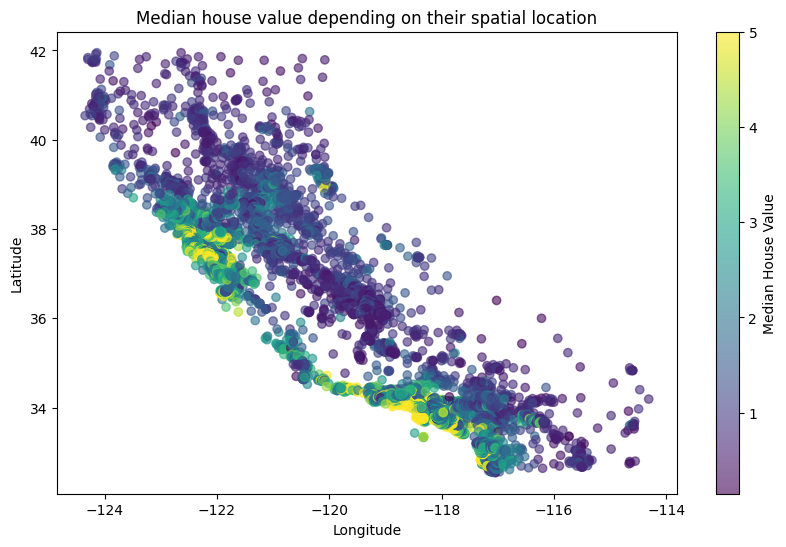

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [7]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], cmap='viridis', alpha=0.6)
cbar = plt.colorbar(sc)
cbar.set_label('Median House Value')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Median house value depending on their spatial location")
plt.show()

print(df)
df['MedHouseVal']

## Part 3: polynomial regression and hyperparameter tuning
In the cell below data for a regression problem is loaded and visualized. There is one input feature (regressor) $x$, stored in `X`, and one target variable (independent variable) $y$, stored in `y`. The data is split into three subsets: a training set, a validation set and a test set. Each of these subsets are represented by an instance of the `Data` class, which has no methods and only 4 attributes: `n_samples`, `random_state`, `X` and `y`.

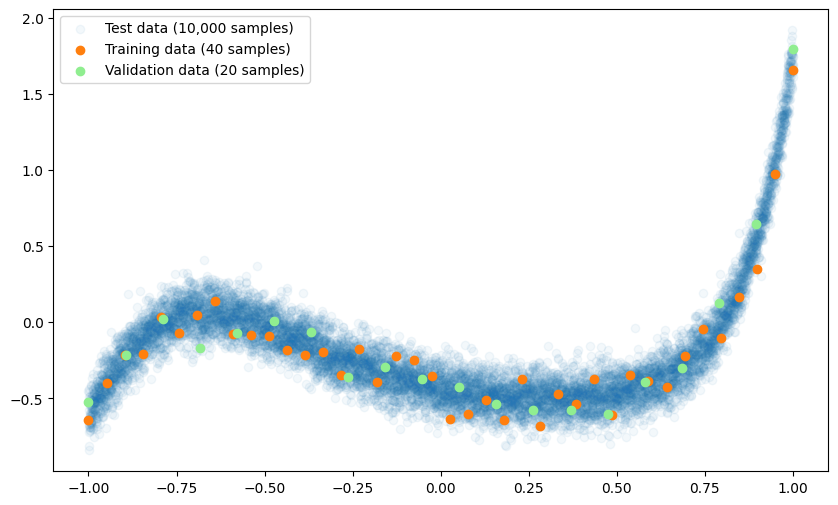

In [8]:
# Dataset class
class Data():

    def __init__(self, n_samples=100, random_state=None, dgp=None):

        self.n_samples = n_samples
        self.random_state = random_state
        self.X, self.y = dgp.generate_data(self.n_samples, self.random_state)

# Importing the datasets
with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)
with open('data/data_val.pkl', 'rb') as f:
    data_val = pickle.load(f)
with open('data/data_test.pkl', 'rb') as f:
    data_test = pickle.load(f)

# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(data_test.X, data_test.y, alpha=0.05, label='Test data (10,000 samples)')
plt.scatter(data_train.X, data_train.y, label='Training data (40 samples)')
plt.scatter(data_val.X, data_val.y, label='Validation data (20 samples)', c='lightgreen')
plt.legend()
plt.show()

**Exercise 9:** A data scientist wants to use a polynomial regression model to predict $y$ given $x$,
$$ y = \sum_{m=0}^M \beta_m x^m , $$
where $\beta_m$ are the parameters of the model and $M$ is the degree of the polynomial. Note that we include an intercept in the model (the term with $m=0$ in the sum). 

The model contains one hyperparameter $M$ that must be tuned. Instead of cross-validation, we use the validation set to tune the hyperparameter. We choose the hyperparameter value that minimizes the RMSE on the validation set, after being trained on the training set.

We pretend that the data scientist does not have access to the test set.

Use the cell below to define a class `PolynomialModel`. This class must (at least) contain methods for training, predicting, computing an RMSE and tuning the hyperparameter of the model. The class must be defined such that the subsequent three cells run without errors and without any alterations of those cells. The output of those cells must be identical to the output in the screenshot `DSM_assignment1_desired_output`.

In [9]:
class PolynomialModel:
    def __init__(self, degree):
        self.degree = degree
        self.model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

    def rmse(self, data):
        X = data.X
        y = data.y
        y_pred = self.predict(X)
        return math.sqrt(mean_squared_error(y, y_pred))

    def hyperparamer_tuning(self, data_train, data_val, verbose=True):
        best_degree = None
        best_rmse = float('inf')
        for degree in range(1, 21):
            self.degree = degree
            self.model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
            self.fit(data_train.X, data_train.y)
            current_rmse = self.rmse(data_val)
            if current_rmse < best_rmse:
                best_rmse = current_rmse
                best_degree = degree
        self.degree = best_degree
        self.model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
        self.fit(data_train.X, data_train.y)
        if verbose:
            print(f"Optimal degree: {best_degree}")
            print(f"Training RMSE: {self.rmse(data_train)}")
            print(f"Validation RMSE: {best_rmse}")
            if self.rmse(data_train) < best_rmse * 0.5:
                print("Warning: The model may be overfitting. Training RMSE is much lower than validation RMSE.")
            else:
                print("The model has been retrained on the full training set with the optimal degree.")

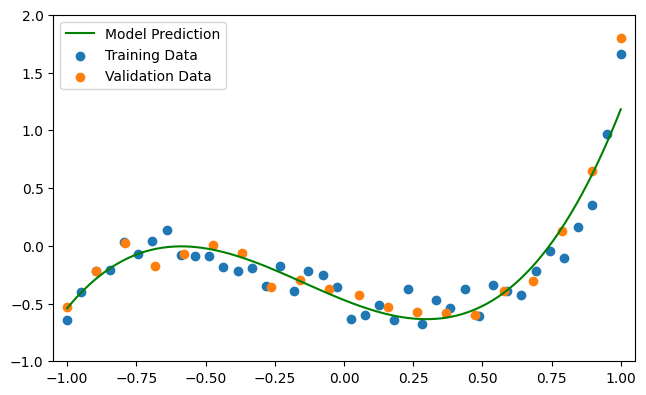

In [10]:
# DO NOT CHANGE THIS CELL!!! #
# Example usage of training and plotting
model = PolynomialModel(degree=3)
model.fit(data_train.X, data_train.y)

plt.figure(figsize=(7.5, 4.5))
X_plot = np.linspace(-1, 1, 100).reshape(-1, 1)
y_plot = model.predict(X_plot)
plt.plot(X_plot, y_plot, label='Model Prediction', color='green')
plt.scatter(data_train.X, data_train.y, label='Training Data')
plt.scatter(data_val.X, data_val.y, label='Validation Data')
plt.ylim(-1, 2)
plt.xlim(-1.05, 1.05)
plt.legend()
plt.show()

In [11]:
# DO NOT CHANGE THIS CELL!!! #
# Example usage of hyperparameter tuning
model = PolynomialModel(degree=1)
model.hyperparamer_tuning(data_train, data_val)

Optimal degree: 8
Training RMSE: 0.0874882122186123
Validation RMSE: 0.10511497132095216
The model has been retrained on the full training set with the optimal degree.


In [12]:
# DO NOT CHANGE THIS CELL!!! #
# Example usage of hyperparameter tuning and testing
model = PolynomialModel(degree=1)
model.hyperparamer_tuning(data_train, data_val, verbose=False)
print("RMSE on test set:", model.rmse(data_test))

RMSE on test set: 0.11258976434306912


**Exercise 10:** suppose now we also have access to the test set. Show explicitly that the optimal degree according to the validation set is not optimal according to the test set (while still using the training set to train the model).

Optimal degree based on validation set: 8, RMSE: 0.10511497132095216
Optimal degree based on test set: 6, RMSE: 0.10569070625116199


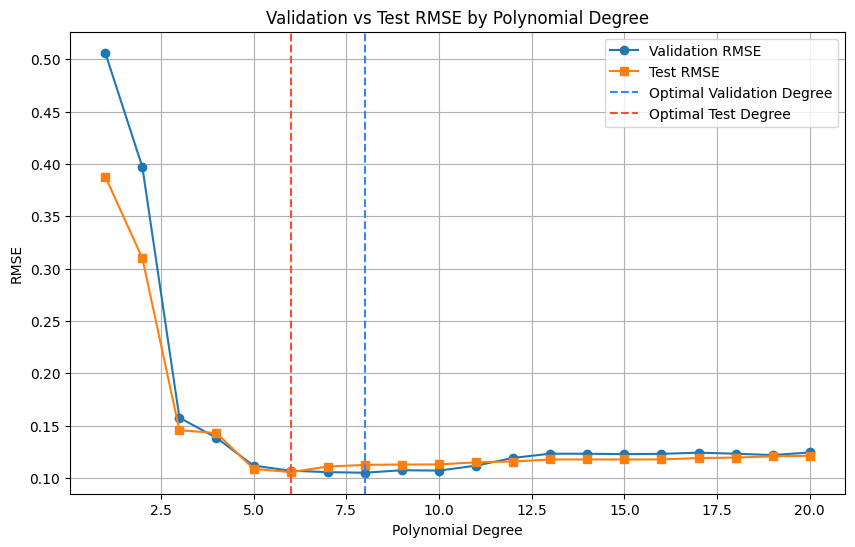

In [13]:
validation_rmses = []
test_rmses = []
degrees = range(1, 21)
#degrees = range(3, 21)

for degree in degrees:
    model = PolynomialModel(degree)
    model.fit(data_train.X, data_train.y)
    
    val_rmse = model.rmse(data_val)
    test_rmse = model.rmse(data_test)
    
    validation_rmses.append(val_rmse)
    test_rmses.append(test_rmse)

# Find optimal degrees
optimal_val_degree = degrees[validation_rmses.index(min(validation_rmses))]
optimal_test_degree = degrees[test_rmses.index(min(test_rmses))]

print(f"Optimal degree based on validation set: {optimal_val_degree}, RMSE: {min(validation_rmses)}")
print(f"Optimal degree based on test set: {optimal_test_degree}, RMSE: {min(test_rmses)}")

# Plotting the RMSEs
plt.figure(figsize=(10, 6))
plt.plot(degrees, validation_rmses, label='Validation RMSE', marker='o')
plt.plot(degrees, test_rmses, label='Test RMSE', marker='s')
plt.axvline(optimal_val_degree, color="#3385FF", linestyle='--', label='Optimal Validation Degree')
plt.axvline(optimal_test_degree, color="#FF4B33", linestyle='--', label='Optimal Test Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Validation vs Test RMSE by Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()
